# Aplicaciones financieras de la computación cuántica
### Carteras de inversión con instrumentos reales: de la frontera eficiente a un circuito cuántico

**XXX Escuela Internacional de Informática · CACIC 2026 · Curso 3: Fundamentos e Intuición del Cómputo Cuántico**  
Juan Pablo Braña · CAETI, Universidad Abierta Interamericana

En esta práctica armamos carteras de inversión con **precios reales** de 12 empresas conocidas y recorremos el camino completo, desde la teoría clásica hasta una computadora cuántica:

| Paso | Qué hacemos | Dónde corre |
|---|---|---|
| 1 | Bajamos precios reales | Yahoo Finance |
| 2 | Teoría moderna de carteras: la frontera eficiente | computadora clásica |
| 3 | Circuitos paramétricos: una perilla que cambia probabilidades | simulador cuántico |
| 4 | Un optimizador cuántico (VQE) elige una cartera | simulador cuántico |
| 5 | Nuestra aproximación: un circuito que estima el riesgo de cada activo | simulador cuántico |
| 6 | Por qué no arrancamos con Hadamard | simulador cuántico |
| 7 | El mismo circuito en una computadora cuántica | IBM Quantum |
| 8 | ¿Sirvió? Evaluación con datos que el modelo nunca vio | computadora clásica |

> **De dónde sale.** El método de la sección 5 es el del trabajo *A Parametric Quantum Circuit for Portfolio Risk Assessment at 110 Qubits* (Braña, Litterio, Fernández et al., QCQSE-Chile, JCC 2026), ejecutado con 110 activos y 110 qubits en una computadora IBM. Acá usamos 12 activos para que todo entre en pantalla.
>
> **Aviso.** Es material educativo. Nada de lo que sigue es una recomendación de inversión.

## 0. Preparación

El notebook corre de arriba hacia abajo en menos de un minuto. Todo lo cuántico se ejecuta en simuladores, salvo la sección 7, que puede enviar el circuito a una computadora real de IBM (opcional).

**Gráficos interactivos.** Los dos gráficos de curvas, el de la sección 1 y el de la sección 8, tienen lupa: arrastrá el mouse sobre una zona para agrandarla y hacé doble clic para volver. Al pasar el mouse se ven los valores de cada curva. La leyenda funciona como filtro: un clic oculta o muestra una curva y doble clic deja una sola. En GitHub se ven como imagen fija.

In [1]:
# En Google Colab, o si te falta algún paquete, descomentá la línea siguiente y ejecutala una sola vez:
# %pip install -q qiskit qiskit-aer qiskit-ibm-runtime yfinance pylatexenc plotly

In [2]:
import json, os, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import minimize
from scipy.stats import spearmanr

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (9, 5), "figure.dpi": 110, "font.size": 12, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

# ----------------------- Configuración de la clase (probá cambiarla) -----------------------
ACTIVOS = {   # ticker: (empresa, sector)
    "AAPL": ("Apple", "Tecnología"),             "MSFT": ("Microsoft", "Tecnología"),
    "AMZN": ("Amazon", "Tecnología"),            "NVDA": ("Nvidia", "Tecnología"),
    "TSLA": ("Tesla", "Consumo discrecional"),   "MELI": ("MercadoLibre", "Consumo discrecional"),
    "JPM":  ("JPMorgan", "Bancos"),              "BAC":  ("Bank of America", "Bancos"),
    "XOM":  ("ExxonMobil", "Energía"),           "CVX":  ("Chevron", "Energía"),
    "KO":   ("Coca-Cola", "Consumo masivo"),     "PEP":  ("PepsiCo", "Consumo masivo"),
}
TICKERS    = list(ACTIVOS)
REFERENCIA = "SPY"                          # fondo que replica el índice S&P 500: "el mercado"
HISTORIA   = ("2023-05-01", "2025-04-30")   # 24 meses: lo único que el modelo puede mirar
FUTURO     = ("2025-05-01", "2026-04-30")   # 12 meses siguientes: solo para evaluar al final
SHOTS      = 4000                           # cuántas veces se repite (y se mide) cada circuito
SEMILLA    = 7                              # para que los resultados se repitan
DATOS      = Path("datos")                  # carpeta con las copias locales

COLOR_SECTOR = {"Tecnología": "#1f6fb2", "Consumo discrecional": "#e07b00", "Bancos": "#0f8b8d",
                "Energía": "#7b4ab8", "Consumo masivo": "#b5477d"}
COLOR = {t: COLOR_SECTOR[sector] for t, (_, sector) in ACTIVOS.items()}
n = len(TICKERS)
print(f"{n} activos -> {n} qubits: {', '.join(TICKERS)}")

12 activos -> 12 qubits: AAPL, MSFT, AMZN, NVDA, TSLA, MELI, JPM, BAC, XOM, CVX, KO, PEP


In [3]:
# Herramienta de presentación: vuelve interactivo un gráfico de curvas. No hace falta leerla para seguir la clase.
def figura_interactiva(fig, grupos=None):
    """Muestra un gráfico de curvas hecho con matplotlib. Si está instalado Plotly, lo vuelve interactivo:
    lupa para agrandar una zona, valores al pasar el mouse y la leyenda como filtro de curvas.
    Guarda también la imagen fija: es lo que se ve en GitHub, o si falta Plotly."""
    from IPython.core.pylabtools import print_figure
    imagen_fija = lambda formato: print_figure(fig, formato, bbox_inches="tight", base64=True,
                                               pil_kwargs={"quality": 90})
    plt.close(fig)
    try:
        import plotly.graph_objects as go
        from matplotlib.colors import to_hex
        from matplotlib.dates import num2date
        ax, grupos, interactiva, con_fechas = fig.axes[0], grupos or {}, go.Figure(), False
        for linea in ax.get_lines():
            nombre, x = linea.get_gid() or linea.get_label(), np.asarray(linea.get_xdata())
            if nombre.startswith("_") or len(x) < 3:                  # líneas sin nombre, o de adorno
                continue
            if np.issubdtype(x.dtype, np.datetime64):                 # fechas como milisegundos: ocupan menos
                x, con_fechas = x.astype("datetime64[ms]").astype(float), True
            interactiva.add_scatter(x=x, y=linea.get_ydata(), name=nombre, mode="lines", opacity=linea.get_alpha(),
                                    line=dict(color=to_hex(linea.get_color()), width=1.4 * linea.get_linewidth()),
                                    legendgroup=grupos.get(nombre), legendgrouptitle_text=grupos.get(nombre))
        for banda in ax.patches:                                      # bandas verticales (axvspan)
            bordes = [banda.get_x(), banda.get_x() + banda.get_width()]
            if con_fechas:
                bordes = [num2date(v).strftime("%Y-%m-%d") for v in bordes]
            interactiva.add_vrect(x0=bordes[0], x1=bordes[1], fillcolor=to_hex(banda.get_facecolor()), line_width=0,
                                  opacity=banda.get_alpha(), layer="below", annotation_text=banda.get_label(),
                                  annotation_position="top left")
        eje_x = dict(title=ax.get_xlabel())
        if con_fechas:                                                # día/mes/año, también al agrandar
            eje_x.update(type="date", hoverformat="%d/%m/%Y",
                         tickformatstops=[dict(dtickrange=[None, "M1"], value="%d/%m/%Y"),
                                          dict(dtickrange=["M1", None], value="%m/%Y")])
        miles = max(abs(v) for v in ax.get_ylim()) >= 1000            # montos grandes: sin decimales y con punto de miles
        eje_y = dict(title=ax.get_ylabel(), type=ax.get_yscale(), hoverformat=",.0f" if miles else ".1f",
                     tickformat=",.0f" if miles else ("~g" if ax.get_yscale() == "log" else None))
        ayuda = dict(text="Clic: ocultar o mostrar<br>Doble clic: dejar una sola", font=dict(size=12, color="gray"))
        interactiva.update_layout(title=ax.get_title(), xaxis=eje_x, yaxis=eje_y, template="plotly_white", height=600,
                                  font_size=14, margin=dict(t=60, b=40, l=60, r=20), hovermode="x unified",
                                  hoverlabel_namelength=-1, separators=",.",        # coma decimal, punto de miles
                                  legend=dict(title=ayuda, groupclick="toggleitem", tracegroupgap=4))
        opciones = {"displaylogo": False, "displayModeBar": True, "showSendToCloud": False}    # sin subir a la nube
        salida = {"application/vnd.plotly.v1+json": {**json.loads(interactiva.to_json()), "config": opciones},
                  "image/jpeg": imagen_fija("jpeg")}
    except Exception:                                             # sin Plotly, o si algo falla, queda la imagen fija
        salida = {"image/png": imagen_fija("png")}
    display(salida, raw=True)

## 1. Datos reales desde Yahoo Finance

Bajamos el **precio de cierre ajustado** de cada día (ya corregido por dividendos y divisiones de acciones).

Partimos el tiempo en dos tramos:

- **HISTORIA** (24 meses): lo único que los modelos pueden mirar para decidir.
- **FUTURO** (los 12 meses siguientes): lo guardamos bajo llave y lo usamos recién al final para evaluar.

Esa separación es la regla de oro: si evaluamos una cartera con los mismos datos con que la armamos, nos engañamos solos.

In [4]:
def bajar_precios(tickers, desde, hasta, copia_local):
    """Precios de cierre ajustados desde Yahoo Finance. Si no hay conexión, usa la copia local."""
    try:
        import yfinance as yf
        fin = (pd.Timestamp(hasta) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
        # threads=False: baja un activo por vez. En paralelo, yfinance a veces falla la primera vez que se usa.
        px = yf.download(tickers, start=desde, end=fin, auto_adjust=True, progress=False, threads=False)["Close"]
        px = px[tickers].dropna()
        assert len(px) > 200, "descarga incompleta"
        origen = "Yahoo Finance (descarga en vivo)"
        if not copia_local.exists():                       # guardamos una copia para trabajar sin conexión
            copia_local.parent.mkdir(parents=True, exist_ok=True)
            px.to_csv(copia_local)
    except Exception as error:
        if not copia_local.exists():
            raise RuntimeError("No pude bajar los datos y no hay copia local en " + str(copia_local)) from error
        px = pd.read_csv(copia_local, index_col=0, parse_dates=True)[tickers]
        origen = f"copia local {copia_local} (no hubo conexión con Yahoo Finance)"
    return px, origen

precios, origen = bajar_precios(TICKERS + [REFERENCIA], "2023-04-25", FUTURO[1], DATOS / "precios_yahoo.csv")
print("Origen:", origen)
print(f"{precios.shape[0]} días de mercado, del {precios.index[0].date()} al {precios.index[-1].date()}")
precios.tail(3).round(2)

Origen: Yahoo Finance (descarga en vivo)
757 días de mercado, del 2023-04-25 al 2026-04-30


Ticker,AAPL,MSFT,AMZN,NVDA,TSLA,MELI,JPM,BAC,XOM,CVX,KO,PEP,SPY
Date,,,,,,,,,,,,,
2026-04-28,270.23,427.52,259.70,212.68,376.02,1791.99,308.51,52.12,148.58,185.04,77.39,153.03,708.10
2026-04-29,269.69,422.75,263.04,208.77,372.80,1767.02,306.33,52.34,152.64,188.83,77.90,152.05,707.99
2026-04-30,270.87,406.13,265.06,199.11,381.63,1792.63,310.28,52.91,152.30,189.90,77.79,155.18,715.04


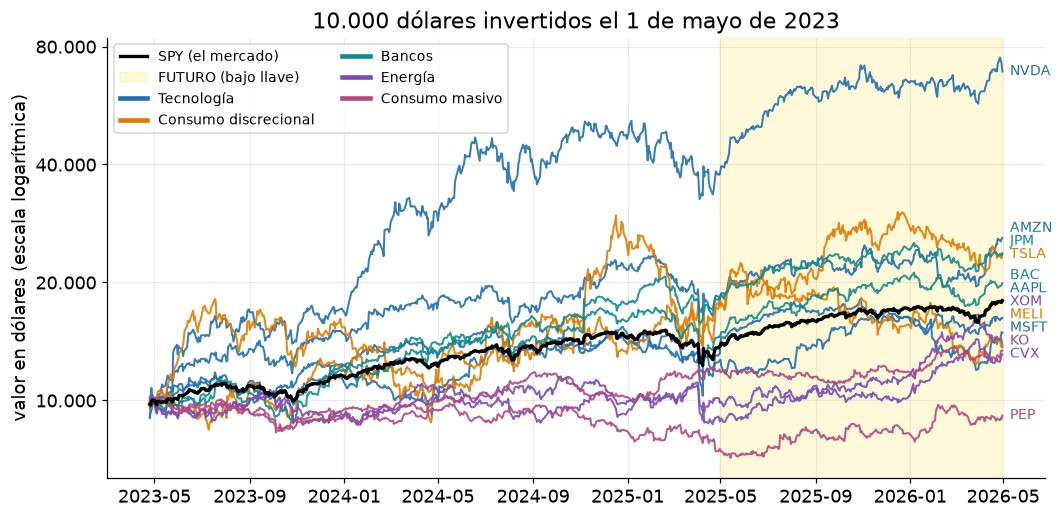

In [5]:
# Evolución de 10.000 dólares invertidos en cada activo al comienzo de HISTORIA (escala logarítmica)
inversion = precios / precios.loc[HISTORIA[0]:].iloc[0] * 10_000
fig, ax = plt.subplots(figsize=(11, 5.2))
for t in TICKERS:
    ax.plot(inversion[t], color=COLOR[t], lw=1.3, alpha=0.9, gid=t)     # gid: nombre de la curva interactiva
altura = 0                                               # etiquetas al final de cada línea, sin encimarse
for t in inversion[TICKERS].iloc[-1].sort_values().index:
    altura = max(inversion[t].iloc[-1], altura * 1.08)
    ax.annotate(t, (inversion.index[-1], altura), xytext=(5, 0), textcoords="offset points", fontsize=9, color=COLOR[t], va="center")
ax.plot(inversion[REFERENCIA], color="black", lw=2.2, label="SPY (el mercado)")
ax.axvspan(pd.Timestamp(FUTURO[0]), precios.index[-1], color="gold", alpha=0.15, label="FUTURO (bajo llave)")
ax.set_yscale("log"); ax.minorticks_off()
ax.set_yticks([5_000, 10_000, 20_000, 40_000, 80_000]); ax.set_yticklabels(["5.000", "10.000", "20.000", "40.000", "80.000"])
ax.set_title("10.000 dólares invertidos el 1 de mayo de 2023"); ax.set_ylabel("valor en dólares (escala logarítmica)")
for sector, color in COLOR_SECTOR.items():
    ax.plot([], [], color=color, lw=3, label=sector)
ax.legend(fontsize=9, ncol=2, loc="upper left")
figura_interactiva(fig, grupos={t: sector for t, (_, sector) in ACTIVOS.items()})

**De precios a retornos.** El retorno diario es cuánto cambió el precio de un día al siguiente. Con los retornos de HISTORIA calculamos, para cada activo, los dos números que usa toda la teoría de carteras:

- **rendimiento anual**: cuánto ganó en promedio por año;
- **volatilidad anual**: cuánto se sacude el precio. Es la medida clásica de **riesgo**.

In [6]:
retornos = np.log(precios / precios.shift(1)).dropna()            # retorno (logarítmico) de cada día
ret_hist = retornos.loc[HISTORIA[0]:HISTORIA[1], TICKERS]         # lo que los modelos pueden mirar

mu  = ret_hist.mean() * 252               # rendimiento anual promedio (252 días de mercado por año)
cov = ret_hist.cov() * 252                # covarianzas anualizadas: cómo se mueven juntos
vol = pd.Series(np.sqrt(np.diag(cov)), index=TICKERS)

resumen = pd.DataFrame({"empresa": [ACTIVOS[t][0] for t in TICKERS], "sector": [ACTIVOS[t][1] for t in TICKERS],
                        "rendimiento anual": mu, "volatilidad anual": vol})
print(f"HISTORIA: {len(ret_hist)} días de retornos")
resumen.sort_values("volatilidad anual").style.format({"rendimiento anual": "{:+.1%}", "volatilidad anual": "{:.1%}"})

HISTORIA: 502 días de retornos


,empresa,sector,rendimiento anual,volatilidad anual
KO,Coca-Cola,Consumo masivo,+9.2%,14.9%
PEP,PepsiCo,Consumo masivo,-14.1%,18.0%
XOM,ExxonMobil,Energía,-2.3%,22.8%
MSFT,Microsoft,Tecnología,+13.4%,22.8%
CVX,Chevron,Energía,-6.6%,23.3%
JPM,JPMorgan,Bancos,+31.1%,23.4%
BAC,Bank of America,Bancos,+18.3%,26.6%
AAPL,Apple,Tecnología,+11.8%,26.7%
AMZN,Amazon,Tecnología,+28.1%,31.2%
MELI,MercadoLibre,Consumo discrecional,+30.2%,39.3%


## 2. Teoría moderna de carteras (Markowitz, 1952)

La idea que le valió el Nobel a Harry Markowitz: **no alcanza con mirar cada activo por separado; importa cómo se mueven juntos**.

Si dos activos no suben y bajan al mismo tiempo, al combinarlos las sacudidas se compensan en parte. Eso es **diversificar**: la cartera puede tener menos riesgo que cualquiera de sus componentes.

A la izquierda, cada activo según su riesgo y su rendimiento. A la derecha, la **correlación**: 1 significa que se mueven igual, 0 que no tienen nada que ver.

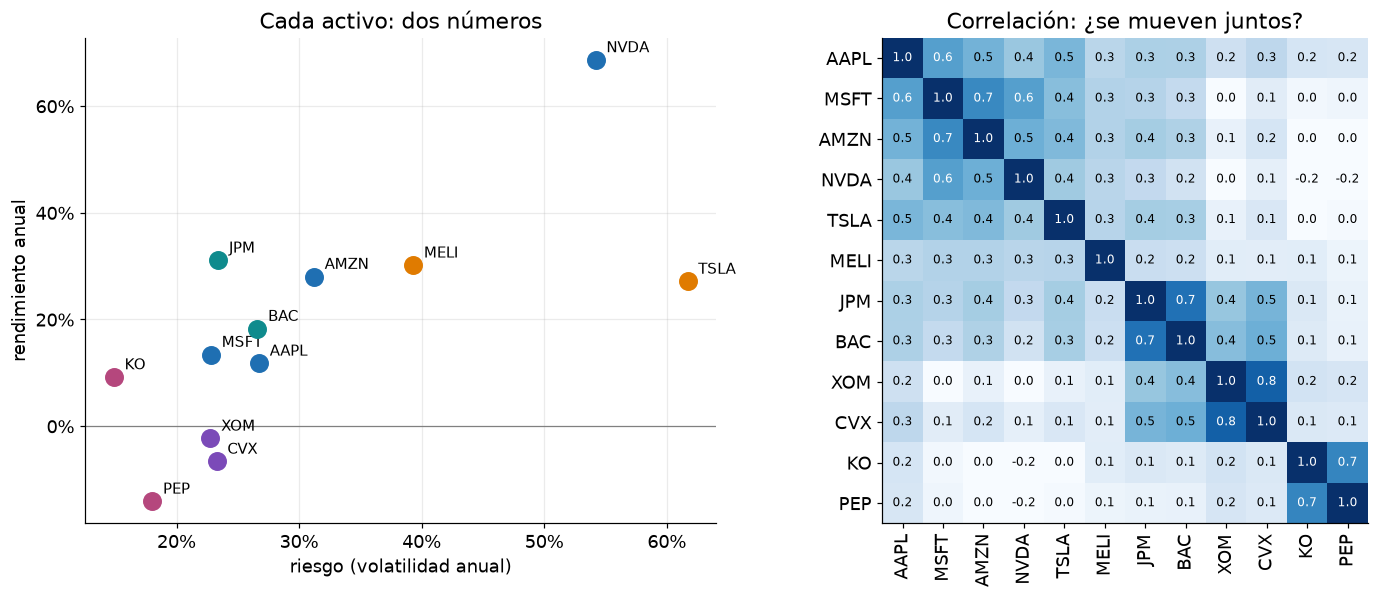

In [7]:
corr = ret_hist.corr()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.6), gridspec_kw={"width_ratios": [1, 1.05]})

for t in TICKERS:
    ax1.scatter(vol[t], mu[t], s=130, color=COLOR[t], zorder=3)
    ax1.annotate(t, (vol[t], mu[t]), xytext=(7, 5), textcoords="offset points", fontsize=10)
ax1.axhline(0, color="gray", lw=0.8)
ax1.set_xlabel("riesgo (volatilidad anual)"); ax1.set_ylabel("rendimiento anual")
ax1.set_title("Cada activo: dos números")
ax1.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}"); ax1.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")

im = ax2.imshow(corr, cmap="Blues", vmin=0, vmax=1)
ax2.set_xticks(range(n)); ax2.set_xticklabels(TICKERS, rotation=90); ax2.set_yticks(range(n)); ax2.set_yticklabels(TICKERS)
for i in range(n):
    for j in range(n):
        v = corr.iloc[i, j]
        ax2.text(j, i, f"{(0.0 if abs(v) < 0.05 else v):.1f}", ha="center", va="center", fontsize=8, color="white" if v > 0.55 else "black")
ax2.set_title("Correlación: ¿se mueven juntos?"); ax2.grid(False)
plt.tight_layout(); plt.show()

### La frontera eficiente

Una **cartera** es una forma de repartir el dinero: un peso para cada activo, que suman 100 %.

Probamos 6.000 carteras al azar (los puntos). Después le pedimos a un optimizador clásico, para cada nivel de rendimiento, **la cartera de menor riesgo posible**. Esa curva es la **frontera eficiente**: no existe ninguna cartera arriba o a la izquierda de ella.

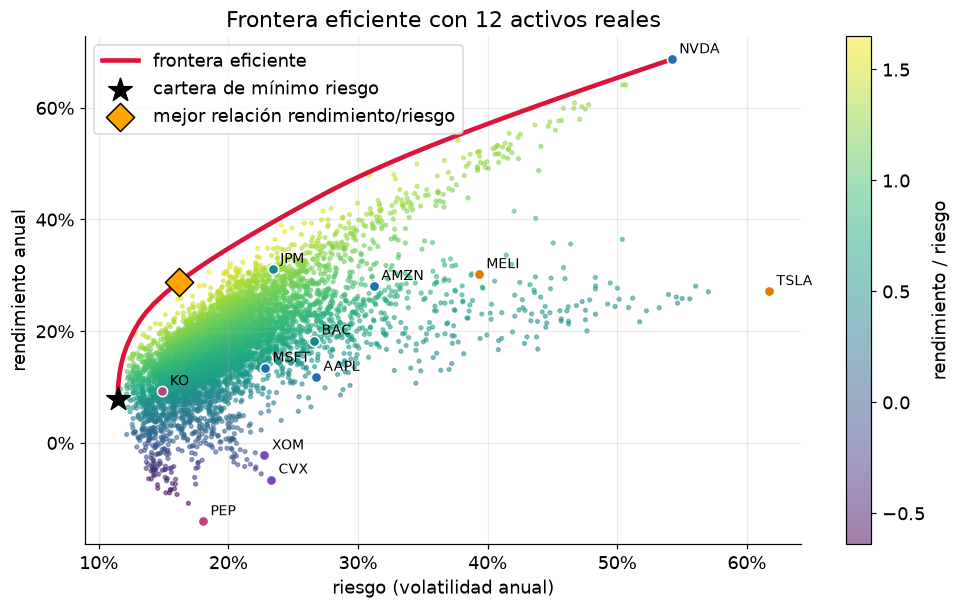

Mínimo riesgo posible: 11.5% anual. El activo menos riesgoso por sí solo tiene 14.9%.
Así reparte el dinero la cartera de mínimo riesgo:
  KO 44%, MSFT 18%, XOM 14%, PEP 12%, JPM 5%, NVDA 2%, CVX 2%, AMZN 1%


In [8]:
m_, S_ = mu.values, cov.values
def rend_y_riesgo(w):                     # (rendimiento, riesgo) de la cartera con pesos w
    return w @ m_, np.sqrt(w @ S_ @ w)

rng = np.random.default_rng(SEMILLA)      # 6.000 carteras al azar (parejas y concentradas)
W = np.vstack([rng.dirichlet(np.ones(n), 3000), rng.dirichlet(np.full(n, 0.2), 3000)])
ret_azar, vol_azar = W @ m_, np.sqrt(np.einsum("ij,jk,ik->i", W, S_, W))

suma_100 = {"type": "eq", "fun": lambda w: w.sum() - 1}      # los pesos suman 100 %
entre_0_y_1 = [(0, 1)] * n                                   # sin vender lo que no se tiene
parejo = np.full(n, 1 / n)

w_min_riesgo = minimize(lambda w: w @ S_ @ w, parejo, bounds=entre_0_y_1, constraints=[suma_100]).x
w_mejor_relacion = minimize(lambda w: -(w @ m_) / np.sqrt(w @ S_ @ w), parejo, bounds=entre_0_y_1, constraints=[suma_100]).x

frontera = []
for objetivo in np.linspace(rend_y_riesgo(w_min_riesgo)[0], m_.max(), 40):
    sol = minimize(lambda w: w @ S_ @ w, parejo, bounds=entre_0_y_1,
                   constraints=[suma_100, {"type": "eq", "fun": lambda w, o=objetivo: w @ m_ - o}])
    if sol.success:
        frontera.append(rend_y_riesgo(sol.x))
frontera = np.array(frontera)

fig, ax = plt.subplots(figsize=(10.5, 6))
puntos = ax.scatter(vol_azar, ret_azar, c=ret_azar / vol_azar, cmap="viridis", s=6, alpha=0.5)
ax.plot(frontera[:, 1], frontera[:, 0], color="crimson", lw=3, label="frontera eficiente")
r1, v1 = rend_y_riesgo(w_min_riesgo); r2, v2 = rend_y_riesgo(w_mejor_relacion)
ax.scatter(v1, r1, s=260, marker="*", color="black", zorder=5, label="cartera de mínimo riesgo")
ax.scatter(v2, r2, s=170, marker="D", color="orange", edgecolor="black", zorder=5, label="mejor relación rendimiento/riesgo")
for t in TICKERS:
    ax.scatter(vol[t], mu[t], s=45, color=COLOR[t], edgecolor="white", zorder=4)
    ax.annotate(t, (vol[t], mu[t]), xytext=(5, 4), textcoords="offset points", fontsize=9)
ax.set_xlabel("riesgo (volatilidad anual)"); ax.set_ylabel("rendimiento anual"); ax.set_title("Frontera eficiente con 12 activos reales")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}"); ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.colorbar(puntos, label="rendimiento / riesgo"); ax.legend(loc="upper left"); plt.show()

print(f"Mínimo riesgo posible: {v1:.1%} anual. El activo menos riesgoso por sí solo tiene {vol.min():.1%}.")
print("Así reparte el dinero la cartera de mínimo riesgo:")
print("  " + ", ".join(f"{t} {p:.0%}" for t, p in sorted(zip(TICKERS, w_min_riesgo), key=lambda par: -par[1]) if p > 0.005))

**Qué nos llevamos de Markowitz**

- Elegir una cartera es un **problema de optimización**: menor riesgo para un rendimiento dado.
- Diversificar funciona: la cartera de mínimo riesgo es menos riesgosa que el mejor activo individual.
- Con 12 activos y pesos continuos, una computadora clásica lo resuelve en milisegundos.

El problema se vuelve difícil cuando las decisiones son de **sí o no**: ¿qué activos entran? Con $n$ activos hay $2^n$ selecciones posibles. Con 12 son 4.096; con 110, más de $10^{33}$. Ahí es donde se exploran heurísticas, clásicas y cuánticas.

## 3. Circuitos paramétricos: una perilla que cambia probabilidades

Un **circuito paramétrico** es un circuito cuántico con **perillas**: compuertas de rotación cuyo ángulo podemos elegir.

La perilla más simple es la compuerta $R_Y(\theta)$ aplicada a un qubit que arranca en $|0\rangle$:

$$R_Y(\theta)\,|0\rangle = \cos\tfrac{\theta}{2}\,|0\rangle + \sin\tfrac{\theta}{2}\,|1\rangle \qquad\Rightarrow\qquad P(\text{medir }1) = \sin^2\tfrac{\theta}{2}$$

Con $\theta = 0$ siempre medimos 0. Con $\theta = \pi$ siempre medimos 1. En el medio, una moneda cargada a gusto.

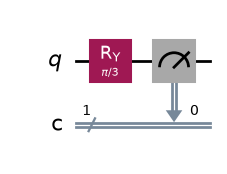

Con theta = pi/3 medimos 1 en el 25.3% de los casos. La fórmula dice 25.0%


In [9]:
def simular(circuito, shots=SHOTS):
    """Simulador ideal (sin ruido): repite el circuito 'shots' veces y cuenta qué salió."""
    resultado = StatevectorSampler(seed=SEMILLA).run([circuito], shots=shots).result()
    return resultado[0].join_data().get_counts()

def frecuencia_de_unos(conteos, n_qubits):
    """Para cada qubit: en qué fracción de las mediciones dio 1."""
    total = sum(conteos.values())
    p1 = np.zeros(n_qubits)
    for cadena, veces in conteos.items():
        for q, bit in enumerate(reversed(cadena)):         # Qiskit escribe el qubit 0 a la derecha
            if bit == "1":
                p1[q] += veces / total
    return p1

def dibujar(circuito, **opciones):
    """Dibuja el circuito. Si falta la librería gráfica (pylatexenc), lo muestra como texto."""
    try:
        display(circuito.draw("mpl", **opciones))
    except Exception:
        print(circuito.draw("text", fold=130))

perilla = QuantumCircuit(1, 1)
perilla.ry(np.pi / 3, 0)             # la perilla: probá otros ángulos
perilla.measure(0, 0)
dibujar(perilla, scale=0.9)
print("Con theta = pi/3 medimos 1 en el", f"{frecuencia_de_unos(simular(perilla), 1)[0]:.1%}", "de los casos. La fórmula dice", f"{np.sin(np.pi / 6) ** 2:.1%}")

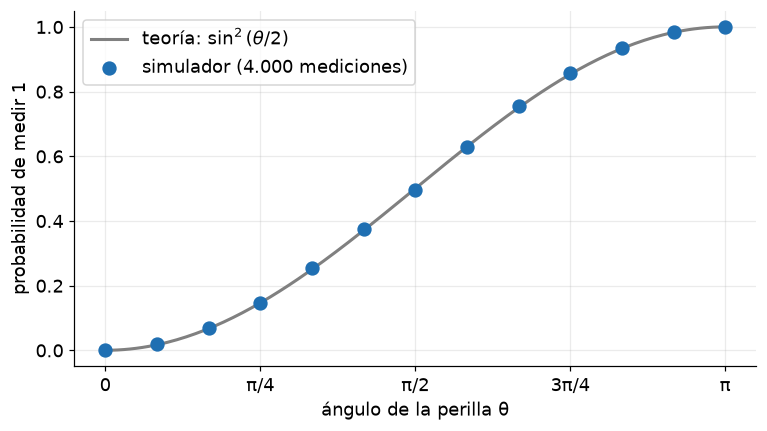

In [10]:
# Giramos la perilla de 0 a pi y medimos 4.000 veces en cada posición
angulos = np.linspace(0, np.pi, 13)
medido = []
for theta in angulos:
    qc = QuantumCircuit(1, 1); qc.ry(theta, 0); qc.measure(0, 0)
    medido.append(frecuencia_de_unos(simular(qc), 1)[0])

fino = np.linspace(0, np.pi, 200)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(fino, np.sin(fino / 2) ** 2, color="gray", lw=2, label=r"teoría: $\sin^2(\theta/2)$")
ax.scatter(angulos, medido, s=70, color="#1f6fb2", zorder=3, label="simulador (4.000 mediciones)")
ax.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi]); ax.set_xticklabels(["0", "π/4", "π/2", "3π/4", "π"])
ax.set_xlabel("ángulo de la perilla θ"); ax.set_ylabel("probabilidad de medir 1"); ax.legend(); plt.show()

### Cargar un número en un qubit

Dando vuelta la fórmula: si queremos que el qubit dé 1 con probabilidad $p$, elegimos

$$\theta = 2\arcsin\sqrt{p}$$

Así se **codifica un dato** (por ejemplo, un riesgo entre 0 y 1) en un qubit.

In [11]:
def angulo(p):
    """Ángulo de la perilla RY que deja P(medir 1) = p."""
    return 2 * np.arcsin(np.sqrt(p))

for p in (0.10, 0.30, 0.75):
    qc = QuantumCircuit(1, 1); qc.ry(angulo(p), 0); qc.measure(0, 0)
    print(f"queremos p = {p:.2f}  ->  theta = {angulo(p):.3f} rad  ->  el simulador midió 1 el {frecuencia_de_unos(simular(qc), 1)[0]:.1%} de las veces")

queremos p = 0.10  ->  theta = 0.644 rad  ->  el simulador midió 1 el 10.0% de las veces
queremos p = 0.30  ->  theta = 1.159 rad  ->  el simulador midió 1 el 30.1% de las veces
queremos p = 0.75  ->  theta = 2.094 rad  ->  el simulador midió 1 el 75.5% de las veces


### Una perilla condicionada: la compuerta CRY

La compuerta $CR_Y(\theta)$ conecta **dos** qubits: gira al segundo **solo si el primero está en** $|1\rangle$.

Nos va a servir para acoplar activos correlacionados. Lo leemos como contagio, *"si el activo A está en problemas, el riesgo de B sube"*, aunque es una interpretación: correlación no es causalidad.

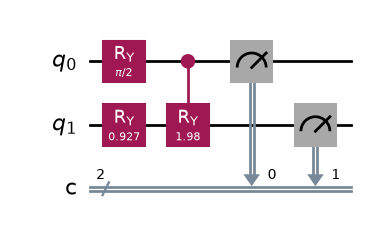

Sin CRY: A = 49.1%   B = 20.5%
Con CRY: A = 49.8%   B = 58.9%   <- B subió: se contagió del riesgo de A


In [12]:
def pareja(riesgo_a, riesgo_b, correlacion=None):
    qc = QuantumCircuit(2, 2)
    qc.ry(angulo(riesgo_a), 0)                     # qubit 0 = activo A
    qc.ry(angulo(riesgo_b), 1)                     # qubit 1 = activo B
    if correlacion is not None:
        qc.cry(angulo(correlacion), 0, 1)          # si A está en |1>, B gira un ángulo extra
    qc.measure([0, 1], [0, 1])
    return qc

dibujar(pareja(0.5, 0.2, 0.7), scale=0.9)
solo = frecuencia_de_unos(simular(pareja(0.5, 0.2)), 2)
junto = frecuencia_de_unos(simular(pareja(0.5, 0.2, 0.7)), 2)
print(f"Sin CRY: A = {solo[0]:.1%}   B = {solo[1]:.1%}")
print(f"Con CRY: A = {junto[0]:.1%}   B = {junto[1]:.1%}   <- B subió: se contagió del riesgo de A")

## 4. El camino más conocido: un optimizador variacional (VQE)

Los dos optimizadores cuánticos más conocidos son:

- **VQE** (*Variational Quantum Eigensolver*, 2014)
- **QAOA** (*Quantum Approximate Optimization Algorithm*, 2014)

Los dos funcionan igual por fuera: un **circuito paramétrico** propone soluciones y un **optimizador clásico** va moviendo las perillas hasta que el resultado mejora. Es un bucle entre la computadora cuántica y la clásica.

**El problema.** De 6 activos queremos elegir exactamente 3. Cada qubit es un activo: 1 = entra, 0 = no entra. Para cada selección calculamos un **costo** (menos es mejor):

$$\text{costo} = \text{aversión} \times \text{riesgo} \;-\; \text{rendimiento} \;+\; \text{multa si no son exactamente 3}$$

Con 6 activos hay $2^6 = 64$ selecciones: podemos revisarlas todas a mano (fuerza bruta) para saber cuál es la respuesta correcta.

In [13]:
MINI     = ["MSFT", "NVDA", "MELI", "JPM", "XOM", "KO"]    # 6 activos -> 6 qubits -> 64 carteras posibles
K        = 3        # cuántos queremos elegir
AVERSION = 5        # cuánto pesa el riesgo frente al rendimiento
MULTA    = 1        # castigo por no elegir exactamente K

mu_m, cov_m, m = mu[MINI].values, cov.loc[MINI, MINI].values, len(MINI)

def costo(x):
    """Costo de una selección x (lista de 0 y 1). Cada activo elegido recibe 1/K del dinero."""
    w = np.array(x) / K
    return AVERSION * (w @ cov_m @ w) - w @ mu_m + MULTA * (sum(x) - K) ** 2

selecciones = [[(i >> q) & 1 for q in range(m)] for i in range(2 ** m)]      # las 64 combinaciones de 0 y 1
costos = np.array([costo(x) for x in selecciones])
ranking = np.argsort(costos)                                                  # de la mejor a la peor
def nombre(i):
    return "+".join(t for t, bit in zip(MINI, selecciones[i]) if bit) or "(ninguno)"

print("Fuerza bruta: las 3 mejores de las 64 carteras")
for puesto, i in enumerate(ranking[:3], 1):
    print(f"  {puesto}. {nombre(i):15s} costo = {costos[i]:+.3f}")

Fuerza bruta: las 3 mejores de las 64 carteras
  1. NVDA+JPM+KO     costo = -0.133
  2. MSFT+JPM+KO     costo = -0.083
  3. MELI+JPM+KO     costo = -0.070


**El circuito paramétrico** (en la jerga, el *ansatz*): una fila de perillas $R_Y$, una cadena de compuertas CNOT que entrelaza los qubits y otra fila de perillas. Son 12 perillas en total.

Al medirlo sale una cartera (una cadena de 6 bits). Según cómo estén las perillas, algunas carteras salen más seguido que otras.

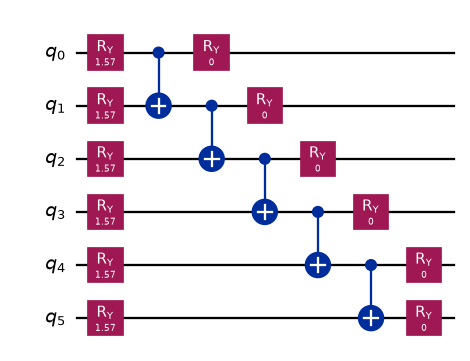

In [14]:
def ansatz(angulos):
    """Circuito paramétrico de 6 qubits y 12 perillas."""
    qc = QuantumCircuit(m)
    for q in range(m):
        qc.ry(angulos[q], q)             # primera fila de perillas
    for q in range(m - 1):
        qc.cx(q, q + 1)                  # entrelazamiento
    for q in range(m):
        qc.ry(angulos[m + q], q)         # segunda fila de perillas
    return qc

inicio = np.concatenate([np.full(m, np.pi / 2), np.zeros(m)])    # arranque: las 64 carteras igual de probables
dibujar(ansatz(np.round(inicio, 2)), scale=0.75)

**El bucle.** En cada vuelta:

1. el circuito nos dice con qué probabilidad sale cada cartera;
2. calculamos el **costo promedio** de lo que saldría al medir;
3. el optimizador clásico (COBYLA, de SciPy) mueve un poco las perillas para bajar ese costo.

En una computadora real el paso 1 se estima midiendo miles de veces. Acá el simulador nos da las probabilidades exactas.

El circuito se ejecutó 400 veces.
VQE eligió: NVDA+JPM+KO  (sale el 100% de las veces)
   como cadena de bits, en el orden MSFT NVDA MELI JPM XOM KO: 010101   (1 = entra, 0 = no entra)
Fuerza bruta dice que la mejor es: NVDA+JPM+KO
-> La cartera de VQE es la número 1 de 64.


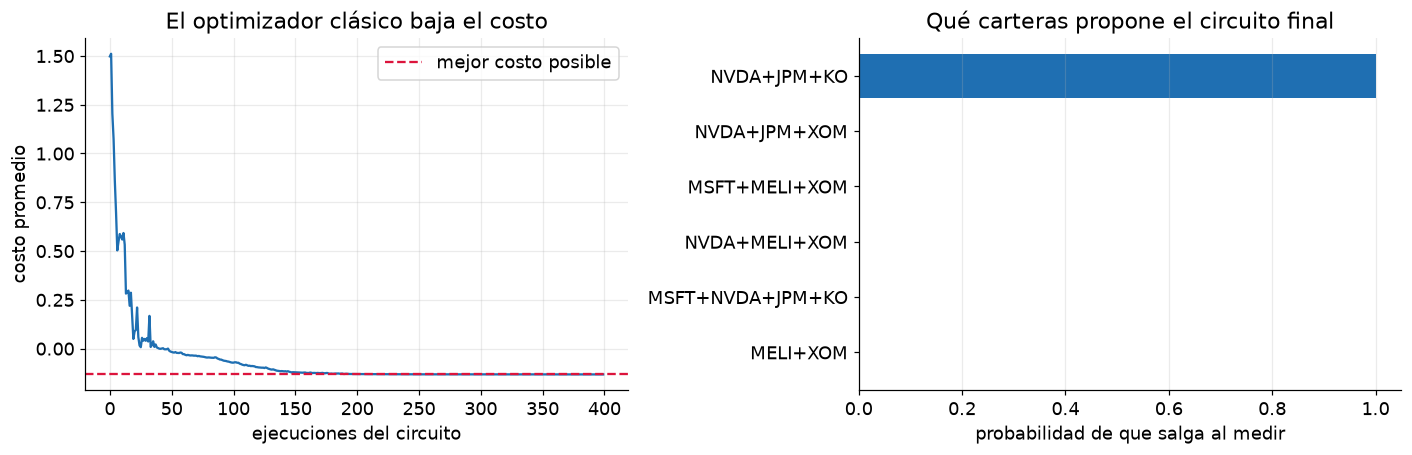

In [15]:
historial = []
def costo_promedio(angulos):
    probabilidades = Statevector(ansatz(angulos)).probabilities()     # una por cada una de las 64 carteras
    valor = float(probabilidades @ costos)
    historial.append(valor)
    return valor

optimo = minimize(costo_promedio, inicio, method="COBYLA", options={"maxiter": 400, "rhobeg": 0.6})

prob_final = Statevector(ansatz(optimo.x)).probabilities()
elegida = int(np.argmax(prob_final))
puesto = int(np.where(ranking == elegida)[0][0]) + 1
print(f"El circuito se ejecutó {len(historial)} veces.")
print(f"VQE eligió: {nombre(elegida)}  (sale el {prob_final[elegida]:.0%} de las veces)")
cadena = "".join(str(b) for b in selecciones[elegida])
print(f"   como cadena de bits, en el orden {' '.join(MINI)}: {cadena}   (1 = entra, 0 = no entra)")
print(f"Fuerza bruta dice que la mejor es: {nombre(ranking[0])}")
print(f"-> La cartera de VQE es la número {puesto} de 64.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.3))
ax1.plot(historial, color="#1f6fb2"); ax1.axhline(costos.min(), color="crimson", ls="--", label="mejor costo posible")
ax1.set_xlabel("ejecuciones del circuito"); ax1.set_ylabel("costo promedio"); ax1.set_title("El optimizador clásico baja el costo"); ax1.legend()
top = np.argsort(-prob_final)[:6]
ax2.barh([nombre(i) for i in top][::-1], prob_final[top][::-1], color="#1f6fb2")
ax2.set_xlabel("probabilidad de que salga al medir"); ax2.set_title("Qué carteras propone el circuito final"); ax2.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**¿Y si arrancamos desde otro lado?** El resultado depende del punto de partida. Probamos 10 arranques con las perillas al azar:

In [16]:
aciertos, ejecuciones = 0, 0
for semilla in range(10):
    arranque = np.random.default_rng(semilla).uniform(0, np.pi, 2 * m)
    cuenta = []
    def f(angulos):
        cuenta.append(1)
        return float(Statevector(ansatz(angulos)).probabilities() @ costos)
    sol = minimize(f, arranque, method="COBYLA", options={"maxiter": 400, "rhobeg": 0.6})
    final = int(np.argmax(Statevector(ansatz(sol.x)).probabilities()))
    aciertos += int(final == ranking[0]); ejecuciones += len(cuenta)
    print(f"  arranque {semilla}: {nombre(final):15s} (puesto {int(np.where(ranking == final)[0][0]) + 1} de 64)")
print(f"\nEncontró la mejor cartera en {aciertos} de 10 arranques, usando {ejecuciones} ejecuciones del circuito en total.")

  arranque 0: MELI+XOM+KO     (puesto 16 de 64)


  arranque 1: NVDA+JPM+KO     (puesto 1 de 64)


  arranque 2: MELI+XOM+KO     (puesto 16 de 64)


  arranque 3: JPM+XOM+KO      (puesto 11 de 64)


  arranque 4: NVDA+JPM+KO     (puesto 1 de 64)


  arranque 5: MELI+JPM+KO     (puesto 3 de 64)


  arranque 6: NVDA+XOM+KO     (puesto 4 de 64)


  arranque 7: MSFT+MELI+JPM   (puesto 8 de 64)


  arranque 8: MSFT+JPM+KO     (puesto 2 de 64)


  arranque 9: NVDA+XOM+KO     (puesto 4 de 64)

Encontró la mejor cartera en 2 de 10 arranques, usando 3853 ejecuciones del circuito en total.


**Qué nos llevamos de VQE y QAOA**

- Son **híbridos**: un circuito cuántico propone y un optimizador clásico corrige, en un bucle.
- Hacen falta **cientos de ejecuciones** del circuito. En hardware real, cada una es un trabajo en la cola.
- Son **heurísticas**: no garantizan la mejor solución y pueden quedar atrapadas en una solución mediocre.
- **QAOA** usa el mismo bucle con un circuito más estructurado: arranca con una compuerta **Hadamard en cada qubit** (todas las carteras a la vez) y alterna capas de "costo" y de "mezcla". Tiene solo 2 perillas por capa.
- Hasta hoy, en carteras con datos reales, los métodos clásicos siguen ganando.

## 5. Nuestra aproximación: un circuito que estima el riesgo de cada activo

Cambiamos la pregunta. En lugar de pedirle al circuito que **busque** la mejor cartera, lo usamos para **estimar un índice de riesgo** de cada activo, y con eso armamos una cartera de bajo riesgo.

- **Un qubit por activo.**
- Una perilla $R_Y$ por activo carga su **riesgo propio**.
- Compuertas $CR_Y$ entre activos muy correlacionados acoplan sus qubits: lo leemos como **contagio**.
- Medimos: la frecuencia con que cada qubit da 1 es el **índice de riesgo** de ese activo.

Lo importante: **no hay bucle de optimización**. Los ángulos se calculan una sola vez, directo de los datos históricos.

### 5.1 El riesgo propio de cada activo

Un **día malo** es un día en que el activo cae más que un desvío estándar de sus propios retornos. Miramos dos cosas:

- **frecuencia**: qué tan seguido tiene días malos;
- **caída media**: cuánto pierde en esos días.

Llevamos cada una a la escala 0 a 1 dentro del grupo, las multiplicamos y volvemos a escalar. El resultado es $R$: 0 para el más tranquilo del grupo, 1 para el más riesgoso. Es un índice relativo al grupo y a la ventana de tiempo, no un riesgo absoluto: $R = 0{,}8$ no significa "80 % de riesgo".

In [17]:
def riesgo_propio(retornos):
    filas = {}
    for t in retornos.columns:
        r = retornos[t]
        dia_malo = r < -r.std()                                   # cayó más que 1 desvío estándar
        filas[t] = {"frecuencia": dia_malo.mean(), "caida_media": -r[dia_malo].mean()}
    tabla = pd.DataFrame(filas).T
    a_escala = lambda v: (v - v.min()) / (v.max() - v.min())      # lleva los valores al rango 0 a 1
    tabla["R"] = a_escala(a_escala(tabla["frecuencia"]) * a_escala(tabla["caida_media"]))
    return tabla

tabla_riesgo = riesgo_propio(ret_hist)
R = tabla_riesgo["R"].values
tabla_riesgo.sort_values("R").style.format({"frecuencia": "{:.1%}", "caida_media": "{:.2%}", "R": "{:.3f}"}).bar(subset=["R"], color="#f2c38b", vmin=0, vmax=1)

,frecuencia,caida_media,R
JPM,7.0%,3.08%,0.000
KO,10.6%,1.56%,0.000
BAC,8.6%,3.01%,0.128
PEP,12.4%,2.04%,0.142
MSFT,11.4%,2.54%,0.236
AAPL,10.6%,3.03%,0.292
XOM,14.1%,2.36%,0.314
CVX,12.2%,2.70%,0.325
AMZN,10.6%,3.37%,0.359
MELI,11.4%,3.97%,0.585


### 5.2 El mapa de contagio

Para cada activo buscamos sus (hasta) 3 vecinos más correlacionados, y solo los conectamos si la correlación es de 0,6 o más. Cada conexión $i \to j$ se lee: *"si $i$ está en problemas, empuja a $j$"*. Es una lectura heurística de la correlación, que no implica causalidad.

8 conexiones: MSFT→AMZN (0.66), AMZN→MSFT (0.66), JPM→BAC (0.75), BAC→JPM (0.75), XOM→CVX (0.82), CVX→XOM (0.82), KO→PEP (0.67), PEP→KO (0.67)


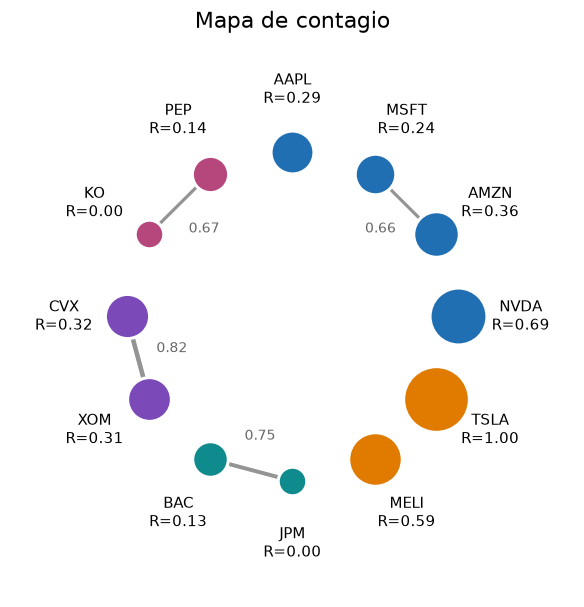

In [18]:
def mapa_de_contagio(corr, vecinos=3, umbral=0.6):
    """Lista de conexiones (i, j, correlación): el activo i contagia al activo j.
    Solo cuentan las correlaciones positivas de umbral o más: una correlación negativa no es contagio."""
    c = corr.values
    fuerza = c.copy(); np.fill_diagonal(fuerza, 0)
    conexiones = []
    for i in range(len(c)):
        for j in np.argsort(-fuerza[i])[:vecinos]:
            if fuerza[i, j] >= umbral:
                conexiones.append((i, int(j), float(c[i, j])))
    return conexiones

conexiones = mapa_de_contagio(corr)
print(f"{len(conexiones)} conexiones:", ", ".join(f"{TICKERS[i]}→{TICKERS[j]} ({c:.2f})" for i, j, c in conexiones))

# Dibujo: cada activo es un círculo (más grande = más riesgo propio); las líneas son las conexiones
ang = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n, endpoint=False)
pos = np.c_[np.cos(ang), np.sin(ang)]
fig, ax = plt.subplots(figsize=(6.6, 6.6))
for i, j, c in conexiones:
    ax.plot(*zip(pos[i], pos[j]), color="gray", lw=1 + 6 * (abs(c) - 0.5), alpha=0.6, zorder=1)
    if i < j:                                             # la correlación, escrita una sola vez por pareja
        ax.annotate(f"{c:.2f}", (pos[i] + pos[j]) / 2 * 0.78, ha="center", va="center", fontsize=9, color="dimgray")
for k, t in enumerate(TICKERS):
    ax.scatter(*pos[k], s=350 + 1500 * R[k], color=COLOR[t], edgecolor="white", lw=2, zorder=2)
    ax.annotate(f"{t}\nR={R[k]:.2f}", pos[k] * 1.38, ha="center", va="center", fontsize=10)
ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7); ax.axis("off"); ax.set_title("Mapa de contagio"); plt.show()

### 5.3 El circuito

Dos capas, en este orden:

1. **Riesgo propio:** $R_Y(\theta_j)$ con $\theta_j = 2\arcsin\sqrt{R_j}$, para que $P(1) = R_j$.
2. **Contagio:** una $CR_Y$ por cada conexión, con ángulo $2\arcsin\sqrt{|\text{correlación}|}$.

Un detalle: recortamos $R$ a 0,95 para que el activo más riesgoso no quede clavado en $|1\rangle$.

12 qubits, 8 compuertas CRY, profundidad 4


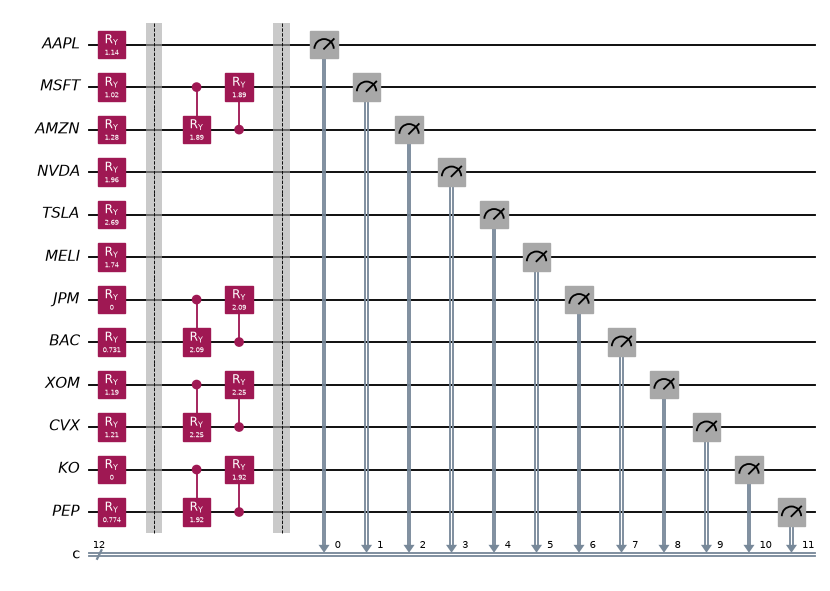

In [19]:
R_circuito = np.minimum(R, 0.95)

def circuito_de_riesgo(R, conexiones, hadamard=False, medir=True, nombres=TICKERS):
    n_q = len(R)
    qc = QuantumCircuit(*[QuantumRegister(1, t) for t in nombres])    # un qubit por activo, con su nombre
    if medir:
        qc.add_register(ClassicalRegister(n_q, "c"))
    if hadamard:                                   # solo para el experimento de la sección 6
        qc.h(range(n_q))
    for j in range(n_q):                           # 1) riesgo propio
        qc.ry(angulo(R[j]), j)
    qc.barrier()
    for i, j, c in conexiones:                     # 2) contagio entre correlacionados
        qc.cry(angulo(min(c, 0.95)), i, j)
    if medir:
        qc.barrier()
        qc.measure(range(n_q), range(n_q))
    return qc

qc_riesgo = circuito_de_riesgo(R_circuito, conexiones)
print(f"{qc_riesgo.num_qubits} qubits, {len(conexiones)} compuertas CRY, profundidad {qc_riesgo.depth()}")
dibujar(qc_riesgo, fold=-1, scale=0.6)

### 5.4 Simulación

Con 12 qubits el simulador puede calcular el resultado **exacto**. También lo corremos como en la vida real: repitiendo 4.000 veces y contando.

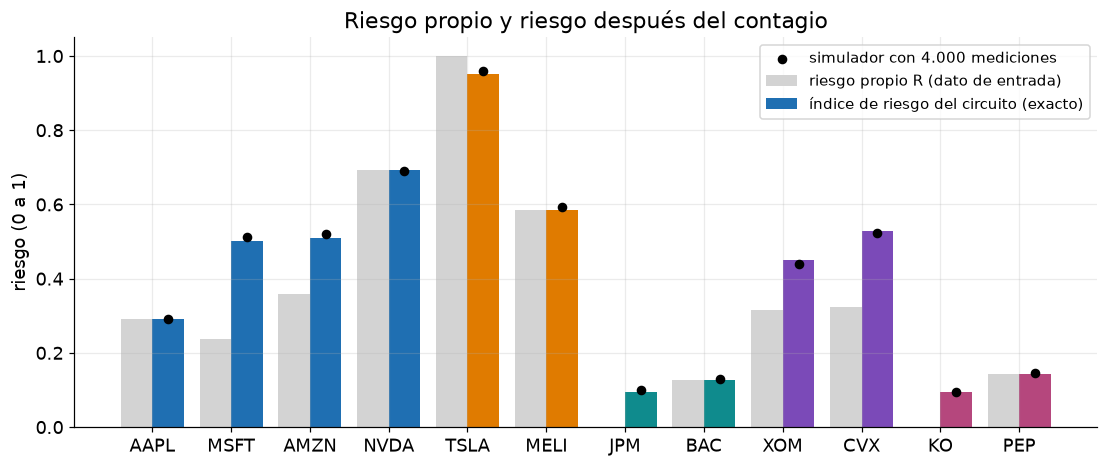

Suben por contagio:         MSFT (+0.27), AMZN (+0.15), JPM (+0.10), XOM (+0.13), CVX (+0.20), KO (+0.10)
Conectados que no cambian:  BAC, PEP
Sin conexiones:             AAPL, NVDA, TSLA, MELI


In [20]:
def indice_exacto(circuito_sin_medir):
    """Probabilidad exacta de que cada qubit dé 1 (sin ruido y sin error de muestreo)."""
    estado = Statevector(circuito_sin_medir)
    return np.array([estado.probabilities([q])[1] for q in range(circuito_sin_medir.num_qubits)])

indice_ideal = indice_exacto(circuito_de_riesgo(R_circuito, conexiones, medir=False))
indice_sim = frecuencia_de_unos(simular(qc_riesgo), n)

x = np.arange(n)
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.bar(x - 0.2, R, 0.4, color="lightgray", label="riesgo propio R (dato de entrada)")
ax.bar(x + 0.2, indice_ideal, 0.4, color=[COLOR[t] for t in TICKERS], label="índice de riesgo del circuito (exacto)")
ax.scatter(x + 0.2, indice_sim, color="black", s=28, zorder=3, label="simulador con 4.000 mediciones")
ax.set_xticks(x); ax.set_xticklabels(TICKERS); ax.set_ylabel("riesgo (0 a 1)"); ax.legend(loc="upper right", fontsize=10)
ax.set_title("Riesgo propio y riesgo después del contagio"); plt.show()

cambio = indice_ideal - R_circuito
contagiados = {j for _, j, _ in conexiones}                # activos que reciben alguna conexión
print("Suben por contagio:        ", ", ".join(f"{t} (+{cambio[k]:.2f})" for k, t in enumerate(TICKERS) if cambio[k] > 0.005))
print("Conectados que no cambian: ", ", ".join(t for k, t in enumerate(TICKERS) if k in contagiados and abs(cambio[k]) <= 0.005))
print("Sin conexiones:            ", ", ".join(t for k, t in enumerate(TICKERS) if k not in contagiados))

**Cómo leerlo.**

- Los activos **sin conexiones** salen con su riesgo propio, tal cual entró.
- Los que tienen una pareja muy correlacionada **suben**: un activo tranquilo, atado a uno más riesgoso, deja de ser tan tranquilo.
- La $CR_Y$ no suma riesgos: en la rama en que el control vale 1, el objetivo queda rotado $\theta_j + \theta_{ij}$ y su probabilidad es $\sin^2\big((\theta_j+\theta_{ij})/2\big)$, que crece mientras la suma no pase de $\pi$. Con estos datos siempre crece.
- Un activo conectado puede **no cambiar** si quien lo contagia tiene riesgo propio 0: ese qubit nunca se "enciende". Con estos datos pasa con BAC y PEP, cuyas parejas (JPM y KO) son las más tranquilas del grupo.

### 5.5 ¿Hace falta lo cuántico? Un modelo clásico de referencia

Para ser honestos, armamos la misma idea **sin** computadora cuántica: el riesgo se difunde por el mismo mapa de contagio (parecido a cómo PageRank reparte importancia entre páginas web). Si el circuito no aporta nada distinto, los dos ordenamientos van a coincidir.

In [21]:
def difusion_clasica(R, conexiones, alfa=0.5, pasos=3):
    """Cada activo mezcla su riesgo propio con el de los vecinos que lo contagian."""
    n_a = len(R)
    W = np.zeros((n_a, n_a))
    for i, j, c in conexiones:
        W[i, j] = abs(c)
    filas = W.sum(axis=1, keepdims=True); filas[filas == 0] = 1
    T = W / filas
    puntaje = R.copy()
    for _ in range(pasos):
        puntaje = (1 - alfa) * R + alfa * (T.T @ puntaje)
    return puntaje

indice_clasico = difusion_clasica(R, conexiones)
comparacion = pd.DataFrame({"riesgo propio R": R, "circuito (ideal)": indice_ideal, "clásico (difusión)": indice_clasico}, index=TICKERS)
print(f"Coincidencia entre el orden del circuito y el del modelo clásico (Spearman, 1 = idénticos): {spearmanr(indice_ideal, indice_clasico).statistic:.2f}")
comparacion.sort_values("circuito (ideal)").style.format("{:.3f}").background_gradient(cmap="Oranges", vmin=0, vmax=1)

Coincidencia entre el orden del circuito y el del modelo clásico (Spearman, 1 = idénticos): 0.92


,riesgo propio R,circuito (ideal),clásico (difusión)
KO,0.000,0.095,0.053
JPM,0.000,0.096,0.048
BAC,0.128,0.128,0.080
PEP,0.142,0.142,0.089
AAPL,0.292,0.292,0.146
XOM,0.314,0.449,0.318
MSFT,0.236,0.502,0.282
AMZN,0.359,0.510,0.313
CVX,0.325,0.529,0.321
MELI,0.585,0.585,0.293


### 5.6 De índice de riesgo a cartera

Regla en dos pasos. **Qué activos entran** lo decide el circuito: los **6 de menor índice de riesgo**. Esa es la parte combinatoria, la de sí o no. **Cuánto va a cada uno** lo decide mínima varianza entre esos 6, es decir, Markowitz dentro del grupo elegido, con un tope de un tercio por activo para no concentrar.

Así cada herramienta hace lo que sabe hacer: el circuito ordena por riesgo con contagio, y el optimizador clásico usa las correlaciones para repartir. La comparación con Markowitz completo sigue siendo exigente: él elige entre los 12 con pesos libres.


In [22]:
def cartera_por_indice_de_riesgo(indice, cuantos=6, tope=1 / 3):
    """Elige los 'cuantos' activos de menor índice de riesgo y reparte el dinero entre ellos
    con pesos de mínima varianza (Markowitz dentro del grupo elegido). Ningún activo pesa más que 'tope'."""
    indice = np.asarray(indice, float)
    elegidos = np.sort(np.argsort(indice)[:cuantos])
    S_e = S_[np.ix_(elegidos, elegidos)]
    sol = minimize(lambda w: w @ S_e @ w, np.full(cuantos, 1 / cuantos), bounds=[(0, tope)] * cuantos, constraints=[suma_100])
    pesos = np.zeros(len(indice))
    pesos[elegidos] = sol.x / sol.x.sum()
    return pesos

w_cuantica = cartera_por_indice_de_riesgo(indice_ideal)
w_clasica = cartera_por_indice_de_riesgo(indice_clasico)
print("Cartera con el índice del circuito:", ", ".join(f"{t} {p:.0%}" for t, p in sorted(zip(TICKERS, w_cuantica), key=lambda par: -par[1]) if p > 0.005))
print("Cartera con el índice clásico:     ", ", ".join(f"{t} {p:.0%}" for t, p in sorted(zip(TICKERS, w_clasica), key=lambda par: -par[1]) if p > 0.005))


Cartera con el índice del circuito: KO 33%, PEP 25%, JPM 16%, XOM 16%, AAPL 10%
Cartera con el índice clásico:      KO 33%, PEP 27%, MSFT 23%, JPM 13%, BAC 5%


## 6. ¿Por qué no arrancamos con Hadamard?

Muchos algoritmos cuánticos empiezan con una compuerta **Hadamard en cada qubit**: deja cada qubit mitad 0 y mitad 1, y así el circuito "ve" todas las combinaciones a la vez. Es lo que hace QAOA.

Nuestra primera versión también empezaba así. Fue un error, y vale la pena entenderlo.

Nosotros no queremos explorar combinaciones: queremos **cargar un número** en cada qubit. Si antes de la perilla ponemos una Hadamard, el qubit ya arranca en 50 %, y la perilla gira desde ahí:

$$\text{sin Hadamard: } P(1) = R \qquad\qquad \text{con Hadamard: } P(1) = \tfrac12 + \sqrt{R\,(1-R)}$$

La segunda fórmula **se pliega**: sube hasta $R = 0{,}5$ y después baja. Dos riesgos muy distintos terminan con la misma lectura.

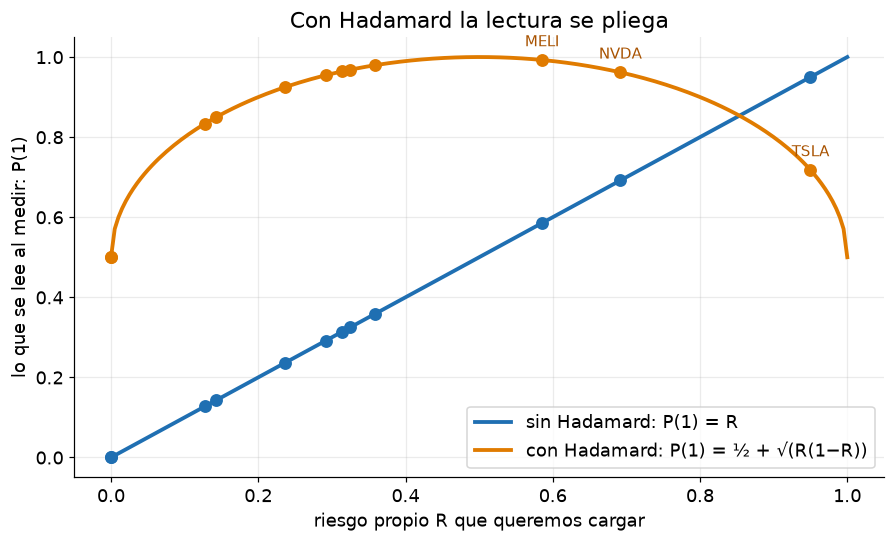

R = 0,25 y R = 0,75 con Hadamard dan lo mismo: 0.933
El más riesgoso (TSLA, R = 0,95) con Hadamard se lee 0.72: parece menos riesgoso que uno de riesgo medio.
¿El orden de riesgo se conserva?  sin Hadamard: 1.00   con Hadamard: 0.61   (1 = se conserva perfecto)


In [23]:
sin_h = indice_exacto(circuito_de_riesgo(R_circuito, [], hadamard=False, medir=False))     # solo la capa de riesgo propio
con_h = indice_exacto(circuito_de_riesgo(R_circuito, [], hadamard=True,  medir=False))

r = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(r, r, color="#1f6fb2", lw=2.5, label="sin Hadamard: P(1) = R")
ax.plot(r, 0.5 + np.sqrt(r * (1 - r)), color="#e07b00", lw=2.5, label="con Hadamard: P(1) = ½ + √(R(1−R))")
ax.scatter(R_circuito, sin_h, color="#1f6fb2", s=55, zorder=3)
ax.scatter(R_circuito, con_h, color="#e07b00", s=55, zorder=3)
for t, x_, y_ in zip(TICKERS, R_circuito, con_h):
    if x_ > 0.5:                                          # nombramos solo a los de mayor riesgo
        ax.annotate(t, (x_, y_), xytext=(0, 9), textcoords="offset points", fontsize=10, ha="center", color="#a85200")
ax.set_xlabel("riesgo propio R que queremos cargar"); ax.set_ylabel("lo que se lee al medir: P(1)")
ax.set_title("Con Hadamard la lectura se pliega"); ax.legend(loc="lower right"); plt.show()

print(f"R = 0,25 y R = 0,75 con Hadamard dan lo mismo: {0.5 + np.sqrt(0.25 * 0.75):.3f}")
print(f"El más riesgoso ({TICKERS[int(np.argmax(R))]}, R = 0,95) con Hadamard se lee {con_h[int(np.argmax(R))]:.2f}: parece menos riesgoso que uno de riesgo medio.")
print(f"¿El orden de riesgo se conserva?  sin Hadamard: {spearmanr(R, sin_h).statistic:.2f}   con Hadamard: {spearmanr(R, con_h).statistic:.2f}   (1 = se conserva perfecto)")

**La regla que nos llevamos**

- **Hadamard** sirve cuando el algoritmo necesita recorrer muchas combinaciones a la vez (QAOA, Grover).
- Para **cargar un dato** en un qubit conviene arrancar en $|0\rangle$ y usar solo la perilla $R_Y$. El qubit igual queda en superposición, pero en la superposición justa: la que tiene $P(1) = R$.

No todos los qubits tienen que empezar en la superposición pareja. Depende de para qué se usa el circuito.

## 7. Del simulador a una computadora cuántica real

Hasta acá todo fue ideal. Una computadora cuántica real tiene dos diferencias:

- **Ruido**: las compuertas y las mediciones fallan un poco.
- **Compuertas y conexiones propias**: el chip no tiene compuertas CRY ni conecta todos los qubits entre sí. Hay que **traducir** el circuito (se llama *transpilar*).

Vamos en dos pasos: primero un **ensayo general** en nuestra máquina, con un simulador que imita el ruido del chip real, y después el chip de verdad.

### 7.1 Ensayo general: simulador con el ruido de `ibm_fez`

`FakeFez` es una copia de las características del procesador **ibm_fez** (IBM Heron r2, 156 qubits), el mismo que usamos en el paper. El código es idéntico al del hardware real; solo cambia el `backend`.

In [24]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeFez

def traducir(circuito, backend):
    """Reescribe el circuito con las compuertas y conexiones del chip."""
    return generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=SEMILLA).run(circuito)

def dos_qubits(circuito):
    """Cantidad de compuertas de dos qubits (las más ruidosas)."""
    return sum(1 for inst in circuito.data if inst.operation.num_qubits == 2)

chip_simulado = FakeFez()
qc_chip = traducir(qc_riesgo, chip_simulado)
print(f"Circuito original : profundidad {qc_riesgo.depth()}, {len(conexiones)} compuertas CRY")
print(f"Circuito traducido: profundidad {qc_chip.depth()}, {dos_qubits(qc_chip)} compuertas de dos qubits, usando {dict(qc_chip.count_ops())}")

sampler = Sampler(mode=chip_simulado)
sampler.options.simulator.seed_simulator = SEMILLA
conteos_ruido = sampler.run([qc_chip], shots=SHOTS).result()[0].join_data().get_counts()
indice_ruido = frecuencia_de_unos(conteos_ruido, n)

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))
print(f"\nRMSE respecto del ideal (la diferencia típica): {rmse(indice_ruido, indice_ideal):.3f}")

Circuito original : profundidad 4, 8 compuertas CRY
Circuito traducido: profundidad 15, 8 compuertas de dos qubits, usando {'sx': 52, 'rz': 44, 'measure': 12, 'cz': 8, 'barrier': 2}



RMSE respecto del ideal (la diferencia típica): 0.010


### 7.2 El chip de verdad: IBM Quantum

Para enviar el circuito a una computadora real hace falta una cuenta gratuita en [IBM Quantum](https://quantum.cloud.ibm.com) y su clave (*API key*). La clave **nunca** se escribe en el notebook: va en un archivo `.env` al lado del notebook (hay una plantilla en `.env.example`) o en una cuenta guardada con `QiskitRuntimeService.save_account(...)`.

La celda siguiente:

- si `EJECUTAR_EN_HARDWARE = True`, envía el circuito, guarda el número de trabajo y espera el resultado;
- si es `False`, muestra el último resultado guardado en `datos/resultado_hardware.json` (o lo va a buscar, si el trabajo ya terminó).

El plan gratuito da 10 minutos de procesador por mes. Este circuito usa unos pocos segundos, pero la **cola de espera** puede ser larga: conviene enviarlo antes de la clase.

In [25]:
EJECUTAR_EN_HARDWARE = False          # <- cambiá a True para enviar el circuito a la computadora cuántica real
BACKEND_REAL = "ibm_fez"              # IBM Heron r2 de 156 qubits (el mismo del paper)
ARCHIVO_HW = DATOS / "resultado_hardware.json"

def conectar_ibm():
    """Conecta con IBM Quantum usando el archivo .env (IBM_API_KEY, IBM_INSTANCE) o la cuenta guardada."""
    from qiskit_ibm_runtime import QiskitRuntimeService
    for archivo in (Path(".env"), Path("../.env"), Path("../../.env")):
        if archivo.exists():
            for linea in archivo.read_text(encoding="utf-8").splitlines():
                if "=" in linea and not linea.strip().startswith("#"):
                    clave, valor = linea.split("=", 1)
                    os.environ.setdefault(clave.strip(), valor.strip().strip('"').strip("'"))
            break
    if os.getenv("IBM_API_KEY"):
        datos_cuenta = {"token": os.environ["IBM_API_KEY"], "channel": os.getenv("IBM_CHANNEL") or "ibm_quantum_platform"}
        if os.getenv("IBM_INSTANCE"):
            datos_cuenta["instance"] = os.environ["IBM_INSTANCE"]
        return QiskitRuntimeService(**datos_cuenta)
    return QiskitRuntimeService()                      # cuenta guardada con save_account(...)

def guardar(registro):
    ARCHIVO_HW.parent.mkdir(parents=True, exist_ok=True)
    ARCHIVO_HW.write_text(json.dumps(registro, indent=1), encoding="utf-8")

if EJECUTAR_EN_HARDWARE:
    backend_real = conectar_ibm().backend(BACKEND_REAL)
    print(f"{backend_real.name}: {backend_real.num_qubits} qubits, {backend_real.status().pending_jobs} trabajos en cola")
    qc_real = traducir(qc_riesgo, backend_real)
    trabajo = Sampler(mode=backend_real).run([qc_real], shots=SHOTS)
    registro = {"backend": backend_real.name, "job_id": trabajo.job_id(), "enviado": datetime.now().isoformat(timespec="seconds"),
                "activos": TICKERS, "R": [round(float(v), 6) for v in R_circuito], "shots": SHOTS,
                "profundidad": qc_real.depth(), "compuertas_2q": dos_qubits(qc_real), "conteos": None}
    guardar(registro)                                  # guardamos el número de trabajo antes de esperar
    print("Trabajo enviado:", registro["job_id"], "| esperando el resultado (se puede interrumpir: el trabajo sigue en la cola)")
    registro["conteos"] = trabajo.result()[0].join_data().get_counts()
    guardar(registro)
    try:
        print(f"Listo. Tiempo de procesador cuántico usado: {trabajo.usage():.0f} segundos")
    except Exception:
        pass

indice_hw, registro = None, None
if ARCHIVO_HW.exists():
    registro = json.loads(ARCHIVO_HW.read_text(encoding="utf-8"))
    if registro["conteos"] is None:                    # se envió antes y todavía no bajamos el resultado
        trabajo = conectar_ibm().job(registro["job_id"])
        print(f"Trabajo {registro['job_id']}: estado {trabajo.status()}")
        if trabajo.done():
            registro["conteos"] = trabajo.result()[0].join_data().get_counts()
            guardar(registro)
    if registro["conteos"] is not None:
        if registro["activos"] == TICKERS and np.allclose(registro["R"], R_circuito, atol=0.02):
            indice_hw = frecuencia_de_unos(registro["conteos"], n)
            print(f"Resultado de hardware real: {registro['backend']}, trabajo {registro['job_id']}, enviado el {registro['enviado']}")
            print(f"Circuito traducido: profundidad {registro['profundidad']}, {registro['compuertas_2q']} compuertas de dos qubits, {registro['shots']} mediciones")
            print(f"RMSE respecto del ideal (la diferencia típica): {rmse(indice_hw, indice_ideal):.3f}")
        else:
            print("Hay un resultado guardado, pero es de otro circuito (cambiaron los activos o los datos). Volvé a enviarlo con EJECUTAR_EN_HARDWARE = True.")
else:
    print("Todavía no hay un resultado de hardware guardado.")
    print("Para obtenerlo: completá el archivo .env, poné EJECUTAR_EN_HARDWARE = True y ejecutá esta celda.")

Resultado de hardware real: ibm_fez, trabajo db1djj3id5ic73er0ceg, enviado el 2026-10-04T19:57:17
Circuito traducido: profundidad 15, 8 compuertas de dos qubits, 4000 mediciones
RMSE respecto del ideal (la diferencia típica): 0.015


**Las cadenas que midió el chip.** Cada medición devuelve 12 bits, uno por activo. Acá un 1 no significa "entra en la cartera", como en VQE, sino "este activo salió en riesgo en esta medición": cada cadena es un **escenario**. En 4.000 mediciones salen cientos de escenarios distintos; abajo, los más frecuentes. El método no usa ninguna cadena en particular: usa la **frecuencia de 1 de cada qubit**, que es su índice de riesgo.


In [26]:
if registro is not None and registro["conteos"] is not None:
    conteos = registro["conteos"]
    print(f"{len(conteos)} cadenas distintas en {sum(conteos.values())} mediciones. Las 5 más frecuentes:")
    for cadena, veces in sorted(conteos.items(), key=lambda kv: -kv[1])[:5]:
        bits = cadena[::-1]                                        # Qiskit escribe el qubit 0 a la derecha
        en_riesgo = [t for t, b in zip(TICKERS, bits) if b == "1"]
        print(f"  {cadena}  {veces:4d} veces   en 1: {', '.join(en_riesgo)}")
    print("Ninguna de estas cadenas es la cartera: la cartera sale de la frecuencia de 1 de cada qubit.")


526 cadenas distintas en 4000 mediciones. Las 5 más frecuentes:
  000000111110   185 veces   en 1: MSFT, AMZN, NVDA, TSLA, MELI
  000000111000   157 veces   en 1: NVDA, TSLA, MELI
  001100111000   156 veces   en 1: NVDA, TSLA, MELI, XOM, CVX
  001100111110   140 veces   en 1: MSFT, AMZN, NVDA, TSLA, MELI, XOM, CVX
  001100011000   131 veces   en 1: NVDA, TSLA, XOM, CVX
Ninguna de estas cadenas es la cartera: la cartera sale de la frecuencia de 1 de cada qubit.


### 7.3 Ideal, ensayo con ruido y hardware

Si todo fuera perfecto, cada punto caería sobre la diagonal.

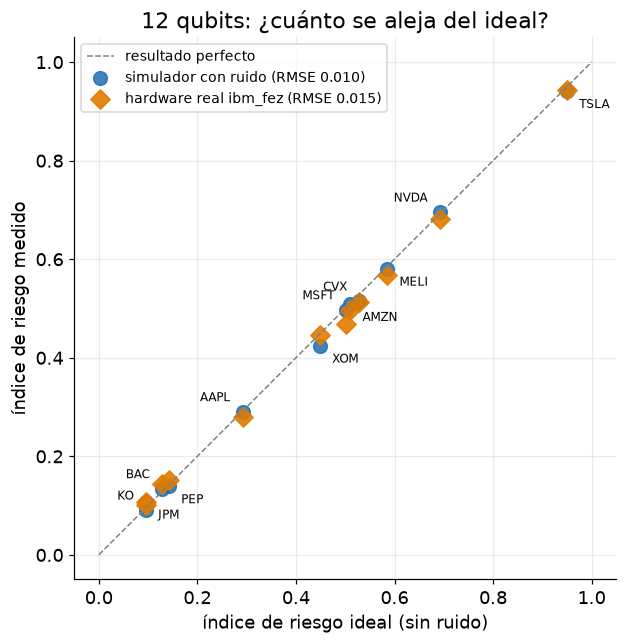

In [27]:
fig, ax = plt.subplots(figsize=(6.8, 6.4))
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="resultado perfecto")
ax.scatter(indice_ideal, indice_ruido, s=80, color="#1f6fb2", alpha=0.85, label=f"simulador con ruido (RMSE {rmse(indice_ruido, indice_ideal):.3f})")
if indice_hw is not None:
    ax.scatter(indice_ideal, indice_hw, s=80, marker="D", color="#e07b00", alpha=0.9,
               label=f"hardware real {registro['backend']} (RMSE {rmse(indice_hw, indice_ideal):.3f})")
for puesto_, k in enumerate(np.argsort(indice_ideal)):        # etiquetas alternadas para que no se pisen
    ax.annotate(TICKERS[k], (indice_ideal[k], indice_ruido[k]), xytext=(8, -11) if puesto_ % 2 else (-8, 7),
                textcoords="offset points", fontsize=8, ha="left" if puesto_ % 2 else "right")
ax.set_xlabel("índice de riesgo ideal (sin ruido)"); ax.set_ylabel("índice de riesgo medido")
ax.set_title("12 qubits: ¿cuánto se aleja del ideal?"); ax.legend(loc="upper left", fontsize=9); ax.set_aspect("equal"); plt.show()

### 7.4 A escala: el experimento real de 110 qubits

Con 12 qubits y un circuito corto, el ruido casi no se nota. El experimento del paper usó **110 activos = 110 qubits** en `ibm_fez`: 129 compuertas CRY que, traducidas al chip, son 551 compuertas de dos qubits con profundidad 391.

Estos son los datos reales de esa corrida (27 de junio de 2026, 5 repeticiones de 4.000 mediciones).

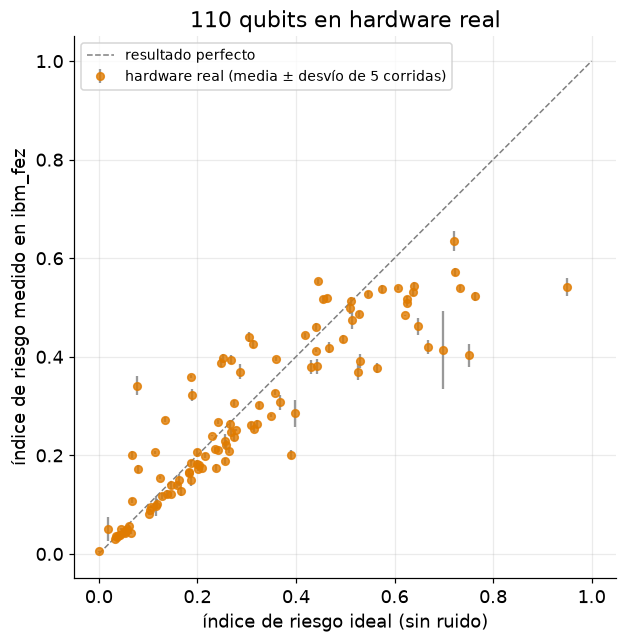

110 activos. Coincidencia del orden con el ideal (Spearman): 0.92
RMSE respecto del ideal (la diferencia típica): 0.102
Los 5 de MENOR riesgo ->  ideal: APD, UL, LMT, LIN, PG  | hardware: APD, LMT, PG, LIN, V
Los 5 de MAYOR riesgo ->  ideal: SMCI, TSLA, SNOW, QCOM, SHOP  | hardware: ENPH, SHOP, TXN, TSM, SMCI


In [28]:
archivo_110 = DATOS / "experimento_110_qubits_ibm_fez.csv"
if archivo_110.exists():
    exp = pd.read_csv(archivo_110)
    fig, ax = plt.subplots(figsize=(6.8, 6.4))
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="resultado perfecto")
    ax.errorbar(exp["q_ideal"], exp["q_hw_mean"], yerr=exp["q_hw_std"], fmt="o", ms=5, color="#e07b00", ecolor="gray", alpha=0.8,
                label="hardware real (media ± desvío de 5 corridas)")
    ax.set_xlabel("índice de riesgo ideal (sin ruido)"); ax.set_ylabel("índice de riesgo medido en ibm_fez")
    ax.set_title("110 qubits en hardware real"); ax.legend(loc="upper left", fontsize=9); ax.set_aspect("equal"); plt.show()
    print(f"{len(exp)} activos. Coincidencia del orden con el ideal (Spearman): {spearmanr(exp['q_ideal'], exp['q_hw_mean']).statistic:.2f}")
    print(f"RMSE respecto del ideal (la diferencia típica): {rmse(exp['q_hw_mean'], exp['q_ideal']):.3f}")
    cinco = lambda columna, mayor: ", ".join(exp.sort_values(columna, ascending=not mayor)["ticker"].head(5))
    print("Los 5 de MENOR riesgo ->  ideal:", cinco("q_ideal", False), " | hardware:", cinco("q_hw_mean", False))
    print("Los 5 de MAYOR riesgo ->  ideal:", cinco("q_ideal", True), " | hardware:", cinco("q_hw_mean", True))
else:
    print("No está el archivo", archivo_110, "(viene con el material de la clase).")

**Cómo leerlo.** El hardware conserva bien el **orden** de riesgo, pero los valores altos se aplastan hacia 0,5: los muy riesgosos se leen menos riesgosos de lo que son. Es la marca del ruido en un circuito largo. En la zona de bajo riesgo, que es la que usamos para armar la cartera, el ideal y el hardware casi coinciden.

## 8. ¿Sirvió? Evaluación con datos que el modelo nunca vio

Abrimos la caja de FUTURO. Compramos cada cartera el último día de HISTORIA y la mantenemos sin tocar durante los 12 meses siguientes.

El objetivo del método es **bajar el riesgo**, así que las columnas que importan son la **volatilidad** y la **máxima caída** (la peor pérdida desde un pico). El rendimiento va solo como referencia.

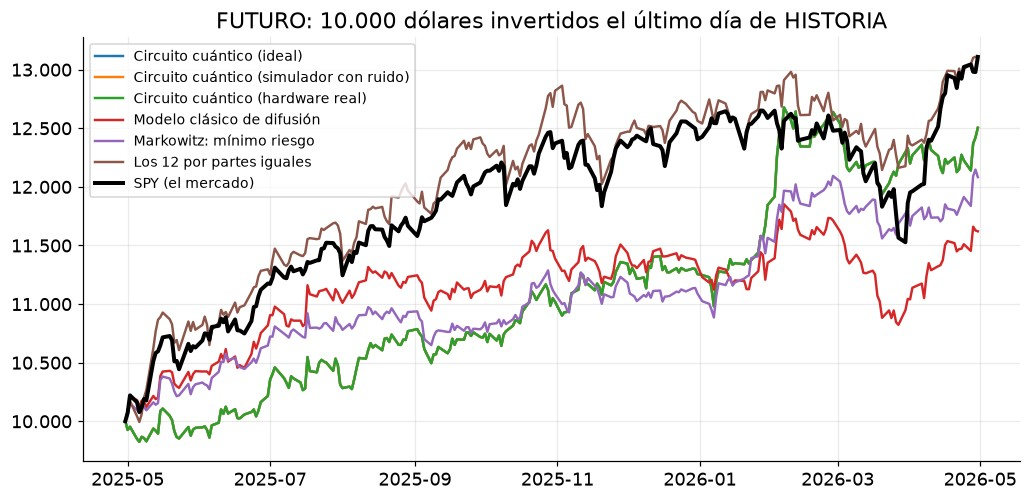

,rendimiento,volatilidad anual,máxima caída
Markowitz: mínimo riesgo,+20.8%,9.6%,-4.4%
Modelo clásico de difusión,+16.2%,10.7%,-8.7%
Circuito cuántico (simulador con ruido),+25.0%,11.3%,-5.8%
Circuito cuántico (ideal),+25.0%,11.3%,-5.8%
Circuito cuántico (hardware real),+25.0%,11.3%,-5.8%
SPY (el mercado),+31.1%,12.5%,-8.9%
Los 12 por partes iguales,+31.0%,12.8%,-6.5%


In [29]:
precio_compra = precios.loc[:HISTORIA[1]].iloc[-1]                 # compramos al cierre del último día de HISTORIA
precios_fut = precios.loc[FUTURO[0]:FUTURO[1]]

def evaluar(pesos, columnas=TICKERS):
    """Comprar y mantener. Devuelve la evolución de 1 dólar y tres medidas."""
    valor = (precios_fut[columnas] / precio_compra[columnas]) @ np.asarray(pesos)
    valor = pd.concat([pd.Series([1.0], index=[precio_compra.name]), valor])
    diario = valor.pct_change().dropna()
    return valor, {"rendimiento": valor.iloc[-1] - 1, "volatilidad anual": diario.std() * np.sqrt(252),
                   "máxima caída": (valor / valor.cummax() - 1).min()}

carteras = {"Circuito cuántico (ideal)": w_cuantica,
            "Circuito cuántico (simulador con ruido)": cartera_por_indice_de_riesgo(indice_ruido)}
if indice_hw is not None:
    carteras["Circuito cuántico (hardware real)"] = cartera_por_indice_de_riesgo(indice_hw)
carteras.update({"Modelo clásico de difusión": w_clasica, "Markowitz: mínimo riesgo": w_min_riesgo,
                 "Los 12 por partes iguales": np.full(n, 1 / n)})

curvas, filas = {}, {}
for nombre_cartera, pesos in carteras.items():
    curvas[nombre_cartera], filas[nombre_cartera] = evaluar(pesos)
curvas["SPY (el mercado)"], filas["SPY (el mercado)"] = evaluar([1.0], [REFERENCIA])

tabla_final = pd.DataFrame(filas).T
fig, ax = plt.subplots(figsize=(11, 5))
for nombre_cartera, curva in curvas.items():
    es_mercado = nombre_cartera.startswith("SPY")
    ax.plot(curva * 10_000, lw=2.6 if es_mercado else 1.6, color="black" if es_mercado else None, label=nombre_cartera)
ax.set_title("FUTURO: 10.000 dólares invertidos el último día de HISTORIA"); ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}".replace(",", "."))          # 12500 se escribe 12.500
figura_interactiva(fig)
tabla_final.sort_values("volatilidad anual").style.format("{:+.1%}", subset=["rendimiento", "máxima caída"]).format("{:.1%}", subset=["volatilidad anual"])

**Cómo leer la tabla, con honestidad**

- Compará la **volatilidad** y la **máxima caída** de cada cartera con las del mercado (SPY): ese es el objetivo del método.
- El circuito cuántico y el modelo clásico de difusión dan volatilidades **parecidas**: parten de los mismos datos y del mismo mapa de contagio. Difieren en la máxima caída porque el clásico elige Microsoft en lugar de Exxon.
- Markowitz, que es puramente clásico, compite de igual a igual o mejor.
- Un año de datos es una sola muestra. No alcanza para sacar conclusiones fuertes.

**¿Entonces hay ventaja cuántica?** No, y hay que decirlo claro. Este circuito se puede simular en una laptop, como hicimos recién. Lo que sí muestra el trabajo:

1. Que un circuito de 110 qubits con datos reales **corre en hardware actual** y se puede validar contra su versión ideal.
2. Una **receta de validación en tres vías** (ideal, hardware, clásico) para separar "el modelo es distinto" de "el hardware tiene ruido".
3. Una **posible línea hacia una ventaja algorítmica**: reformular la estimación de riesgo para usar este circuito dentro de la *estimación de amplitud cuántica* (QAE), que en teoría ofrece una mejora cuadrática en la cantidad de muestras frente al método clásico de Monte Carlo, bajo ciertas condiciones. En la práctica necesita computadoras con corrección de errores.

## 9. Para seguir probando

1. **Cambiá los activos.** En la configuración, reemplazá algún ticker (por ejemplo `"GGAL"` o `"YPF"`, que cotizan en Nueva York) y volvé a correr todo.
2. **Mové el umbral de contagio.** En `mapa_de_contagio(corr, umbral=0.5)` aparecen más conexiones. ¿Qué pasa con la profundidad del circuito traducido?
3. **Probá el error de Hadamard completo.** Armá `circuito_de_riesgo(R_circuito, conexiones, hadamard=True)` y compará el orden de riesgo con el correcto.
4. **Más perillas para VQE.** Agregale otra capa al `ansatz`. ¿Encuentra la mejor cartera más seguido? ¿Cuántas ejecuciones más necesita?
5. **Hardware real.** Creá tu cuenta gratuita en IBM Quantum, completá el `.env` y poné `EJECUTAR_EN_HARDWARE = True`.

### Para leer más

- H. Markowitz, "Portfolio selection", *Journal of Finance*, 1952.
- A. Peruzzo et al., "A variational eigenvalue solver on a photonic quantum processor", *Nature Communications*, 2014 (VQE).
- E. Farhi, J. Goldstone y S. Gutmann, "A Quantum Approximate Optimization Algorithm", arXiv:1411.4028, 2014 (QAOA).
- S. Woerner y D. J. Egger, "Quantum risk analysis", *npj Quantum Information*, 2019 (estimación de amplitud para riesgo).
- J. P. Braña, A. M. J. Litterio, A. Fernández et al., "A Parametric Quantum Circuit for Portfolio Risk Assessment at 110 Qubits", QCQSE-Chile, JCC 2026.
- Documentación de Qiskit e IBM Quantum: https://quantum.cloud.ibm.com/docs